# CIFAR 10 Exercise

We explore 3 different techniques which will later be utilized in anomaly detection algorithms
1. CNNs
2. PCA
3. Autoencoders

# CNN

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision 
import torchvision.transforms as transforms
import torchsummary as summary
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_built() and torch.backends.mps.is_available():
    device = torch.device("mps")
print(device)

cuda


## 1. Obtaining and prepocessing data

ToTensor - converts values to 0 and 1, and chages shape from 32x32x3 to 3x32x32.
Normalize - first tuple is the mean, 1 value for each channel. second tuple is the sd. new_val = (old_val - 0.5)/0.5. Therefore this normalizes value to be between -1 and 1 which is what CNN prefer.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

Now we can load in the data, and pass in our transform

In [4]:
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download = True, transform=transform)

c:\Users\nikol\Documents\UROP2026\mini_projs\cifar10\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Here we pass the images in a DataLoader(). This is a tool that helps feed the images into our model in chunks (in this case 4). We shuffle the training data which prevents the model from learning the order, and help it to generalize better.

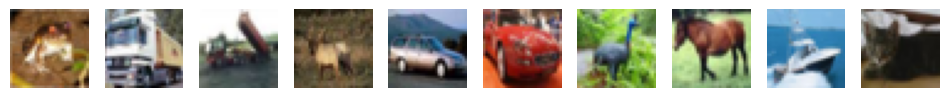

In [5]:
train_loader = torch.utils.data.DataLoader(train_set, batch_size=4, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=4, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i in range(10):
    image = train_loader.dataset[i][0].permute(1, 2, 0)
    denormalized_image = image /2 + 0.5
    axes[i].imshow(denormalized_image)
    axes[i].axis('off')
plt.show()

## 2. Create our CNN, and construct our forward path.

In [6]:
class ConvNeuraNet(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.conv1 = nn.Conv2d(3, 64, 3)
        self.conv2 = nn.Conv2d(64, 128, 3)

        self.pool = nn.MaxPool2d(2, stride=2)

        self.fc1 = nn.Linear(128 * 6 * 6, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.log_softmax(self.fc3(x), dim=1)
        return x
    

net = ConvNeuraNet()
net.to(device)

ConvNeuraNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4608, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

## 3. Train our model

In [7]:
loss_function = nn.NLLLoss() # this calculates the average loss per batch.
optimizer = optim.Adam(net.parameters(), lr=0.001)

epochs = 10

train_loss_per_epoch = []
val_loss_per_epoch = []

for epoch in range(epochs):

    net.train()

    #rtl: running train loss
    avg_batch_rtl = 0.0
    ttl_batch_rtl = 0.0

    for i, data in enumerate(train_loader):
        # i: batch index
        # data: (image_batch, label_batch)
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        avg_batch_rtl += loss.item()
        ttl_batch_rtl += loss.item() * inputs.size(0)
        
        if i % 2000 == 1999:
            print(f'[{epoch + 1}/{epochs}, {i + 1:5d}] loss: {avg_batch_rtl / 2000:.3f}')
            avg_batch_rtl = 0.0
    avg_epoch_loss = ttl_batch_rtl / len(train_loader.dataset)
    train_loss_per_epoch.append(avg_epoch_loss)

    net.eval()

    # rvl: running validation loss
    ttl_batch_rvl = 0.0
    with torch.no_grad():
        for i,data in enumerate(test_loader):
            inputs, labels = data[0].to(device), data[1].to(device)

            outputs = net(inputs)
            loss = loss_function(outputs, labels)

            ttl_batch_rvl += loss.item() * inputs.size(0)

    avg_val_epoch_loss = ttl_batch_rvl / len(test_loader.dataset)
    val_loss_per_epoch.append(avg_val_epoch_loss)

    print(
        f'Epoch {epoch+1}/{epochs}, '
        f'Train loss: {avg_epoch_loss:.3f}, '
        f'Validation loss: {avg_val_epoch_loss:.3f}'
    )
print('finished training')

[1/10,  2000] loss: 1.806
[1/10,  4000] loss: 1.476
[1/10,  6000] loss: 1.396
[1/10,  8000] loss: 1.315
[1/10, 10000] loss: 1.264
[1/10, 12000] loss: 1.227
Epoch 1/10, Train loss: 1.405, Validation loss: 1.212
[2/10,  2000] loss: 1.141
[2/10,  4000] loss: 1.138
[2/10,  6000] loss: 1.109
[2/10,  8000] loss: 1.066
[2/10, 10000] loss: 1.055
[2/10, 12000] loss: 1.052
Epoch 2/10, Train loss: 1.091, Validation loss: 1.117
[3/10,  2000] loss: 0.972
[3/10,  4000] loss: 0.974
[3/10,  6000] loss: 0.982
[3/10,  8000] loss: 0.979
[3/10, 10000] loss: 0.986
[3/10, 12000] loss: 0.957
Epoch 3/10, Train loss: 0.973, Validation loss: 0.986
[4/10,  2000] loss: 0.871
[4/10,  4000] loss: 0.908
[4/10,  6000] loss: 0.914
[4/10,  8000] loss: 0.905
[4/10, 10000] loss: 0.917
[4/10, 12000] loss: 0.908
Epoch 4/10, Train loss: 0.905, Validation loss: 0.978
[5/10,  2000] loss: 0.824
[5/10,  4000] loss: 0.852
[5/10,  6000] loss: 0.838
[5/10,  8000] loss: 0.853
[5/10, 10000] loss: 0.867
[5/10, 12000] loss: 0.858
Epoc

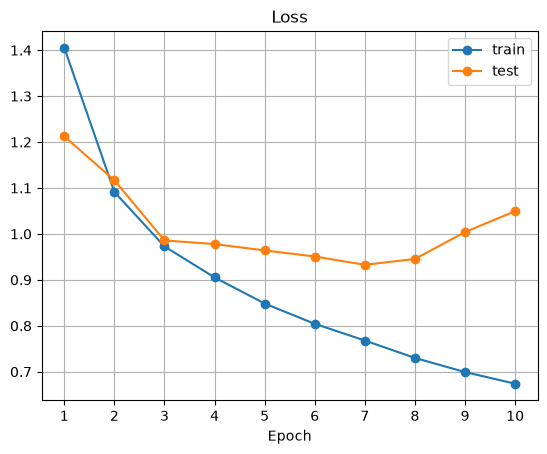

In [8]:
x_axis = np.arange(1,11)
plt.figure()
plt.plot(x_axis, train_loss_per_epoch, marker='o', label='train')
plt.plot(x_axis, val_loss_per_epoch, marker='o', label='test')
plt.title('Loss')
plt.xlabel('Epoch')
plt.grid()
plt.xticks(x_axis)
plt.legend()

## 4. Adding droupout to deal with overfitting

In [28]:
class ConvNeuraNet_dropout(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.conv1 = nn.Conv2d(3, 64, 3)
        self.conv2 = nn.Conv2d(64, 128, 3)

        self.pool = nn.MaxPool2d(2, stride=2)

        # Dropout layers
        self.dropout_2d = nn.Dropout2d(p=0.25)
        self.droptout_fc = nn.Dropout(p=0.5)

        self.fc1 = nn.Linear(128 * 6 * 6, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)

        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout_2d(x) # dropout layer after convolution layers

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.droptout_fc(x) # dropout layer after first neural layer

        x = F.relu(self.fc2(x))
        x = self.droptout_fc(x) # dropout layer after second neural layer

        x = F.log_softmax(self.fc3(x), dim=1)
        return x
    
net = ConvNeuraNet_dropout()
net.to(device)

ConvNeuraNet_dropout(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout_2d): Dropout2d(p=0.25, inplace=False)
  (droptout_fc): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=4608, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Retrain our model

In [10]:
optimizer = optim.Adam(net.parameters(), lr=0.001)

train_loss_per_epoch = []
val_loss_per_epoch = []

for epoch in range(epochs):

    net.train()

    #rtl: running train loss
    avg_batch_rtl = 0.0
    ttl_batch_rtl = 0.0

    for i, data in enumerate(train_loader):
        # i: batch index
        # data: (image_batch, label_batch)
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        avg_batch_rtl += loss.item()
        ttl_batch_rtl += loss.item() * inputs.size(0)
        
        if i % 2000 == 1999:
            print(f'[{epoch + 1}/{epochs}, {i + 1:5d}] loss: {avg_batch_rtl / 2000:.3f}')
            avg_batch_rtl = 0.0
    avg_epoch_loss = ttl_batch_rtl / len(train_loader.dataset)
    train_loss_per_epoch.append(avg_epoch_loss)

    net.eval()

    # rvl: running validation loss
    ttl_batch_rvl = 0.0
    with torch.no_grad():
        for i,data in enumerate(test_loader):
            inputs, labels = data[0].to(device), data[1].to(device)

            outputs = net(inputs)
            loss = loss_function(outputs, labels)

            ttl_batch_rvl += loss.item() * inputs.size(0)

    avg_val_epoch_loss = ttl_batch_rvl / len(test_loader.dataset)
    val_loss_per_epoch.append(avg_val_epoch_loss)

    print(
        f'Epoch {epoch+1}/{epochs}, '
        f'Train loss: {avg_epoch_loss:.3f}, '
        f'Validation loss: {avg_val_epoch_loss:.3f}'
    )
print('finished training')

[1/10,  2000] loss: 2.100
[1/10,  4000] loss: 1.917
[1/10,  6000] loss: 1.815
[1/10,  8000] loss: 1.756
[1/10, 10000] loss: 1.716
[1/10, 12000] loss: 1.674
Epoch 1/10, Train loss: 1.823, Validation loss: 1.478
[2/10,  2000] loss: 1.635
[2/10,  4000] loss: 1.597
[2/10,  6000] loss: 1.644
[2/10,  8000] loss: 1.583
[2/10, 10000] loss: 1.572
[2/10, 12000] loss: 1.536
Epoch 2/10, Train loss: 1.592, Validation loss: 1.392
[3/10,  2000] loss: 1.518
[3/10,  4000] loss: 1.503
[3/10,  6000] loss: 1.493
[3/10,  8000] loss: 1.509
[3/10, 10000] loss: 1.499
[3/10, 12000] loss: 1.478
Epoch 3/10, Train loss: 1.498, Validation loss: 1.291
[4/10,  2000] loss: 1.444
[4/10,  4000] loss: 1.425
[4/10,  6000] loss: 1.452
[4/10,  8000] loss: 1.445
[4/10, 10000] loss: 1.443
[4/10, 12000] loss: 1.418
Epoch 4/10, Train loss: 1.439, Validation loss: 1.273
[5/10,  2000] loss: 1.385
[5/10,  4000] loss: 1.392
[5/10,  6000] loss: 1.396
[5/10,  8000] loss: 1.401
[5/10, 10000] loss: 1.400
[5/10, 12000] loss: 1.392
Epoc

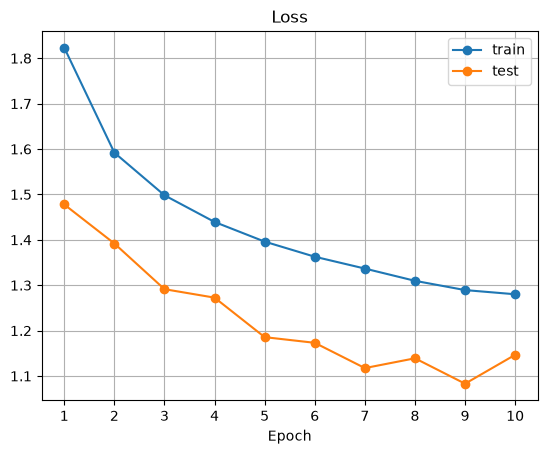

In [11]:
x_axis = np.arange(1,11)
plt.figure()
plt.plot(x_axis, train_loss_per_epoch, marker='o', label='train')
plt.plot(x_axis, val_loss_per_epoch, marker='o', label='test')
plt.title('Loss')
plt.xlabel('Epoch')
plt.grid()
plt.xticks(x_axis)
plt.legend()

In [ ]:
#torch.save(net.state_dict(), "cnn_cifar10.pth")

## 5. Evaluating our model

In [37]:
net = ConvNeuraNet_dropout()
net.to(device)

state_dict = torch.load(
    "cnn_cifar10.pth",
    map_location=device,
    weights_only=True
)

net.load_state_dict(state_dict)

<All keys matched successfully>

In [40]:
net.eval()

correct = 0
total = 0

with torch.no_grad():
    for i, data in enumerate(test_loader):

        inputs, labels = data[0].to(device), data[1].to(device)

        outputs = net(inputs)

        _, prediction = torch.max(outputs, dim=1)

        total += labels.shape[0] # labels.shape = [4]
        correct += (prediction == labels).sum().item()
        # (prediction == labels): [True, False, True, False] etc.
        # (prediction == labels).sum() = tensor(2)
        # .item() = 2

accuracy = round(correct/total * 100,2)

print(f'Accuracy: {accuracy}%')
        
        

Accuracy: 61.66%


# PCA

## 1. Reshape data into a matrix

In [6]:
# original shape
print(train_set.data.shape, test_set.data.shape)

(50000, 32, 32, 3) (10000, 32, 32, 3)


In [7]:
train_mat = train_set.data.reshape(len(train_set.data), -1).astype(np.float32)
test_mat = test_set.data.reshape(len(test_set.data), -1).astype(np.float32)

print(train_mat.data.shape, test_mat.data.shape)

(50000, 3072) (10000, 3072)


## 2. Center the Data

recall

In [8]:
train_mat /= 255.0
test_mat /= 255.0

train_avg = train_mat.mean(axis=0)

train_mat_centered = train_mat - train_avg
test_mat_centered = test_mat - train_avg

## 3. Take the randomized SVD

In [9]:
from sklearn.utils.extmath import randomized_svd

In [10]:
U, S, VT = randomized_svd(
    train_mat_centered,
    n_components=200
)

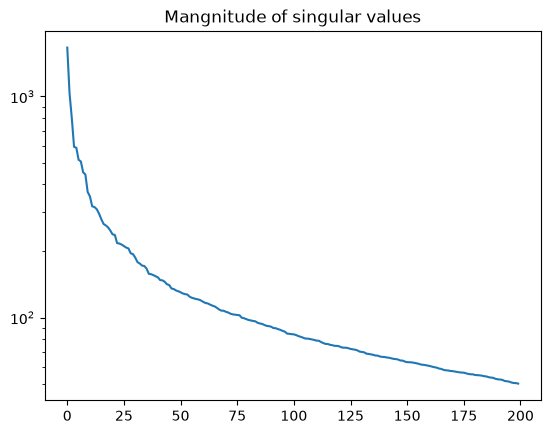

In [11]:
plt.figure()
plt.semilogy(S)
plt.title("Mangnitude of singular values")
plt.show()

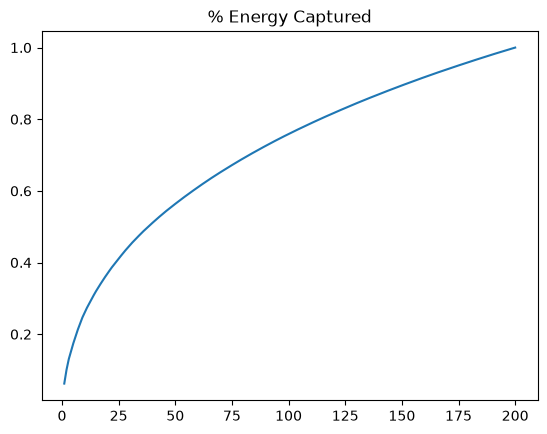

In [12]:
plt.figure()
plt.plot(range(1, len(S)+1), np.cumsum(S)/np.sum(S))
plt.title("% Energy Captured")
plt.show()

## 4. Train a classifier based on PCA result

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
X_train_PCA = U * S
y_train = train_set.targets

X_test_PCA = test_mat_centered @ VT.T
y_test = test_set.targets

In [15]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_PCA, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](10,)","[0,1,2,...,7,8,9]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [16]:
y_pred = knn.predict(X_test_PCA)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Classification report: ", classification_report(y_test, y_pred))
print("Confusion Matrix: ", confusion_matrix(y_test, y_pred))


Accuracy:  0.3625
Classification report:                precision    recall  f1-score   support

           0       0.39      0.57      0.46      1000
           1       0.65      0.26      0.37      1000
           2       0.24      0.46      0.31      1000
           3       0.30      0.20      0.24      1000
           4       0.25      0.50      0.34      1000
           5       0.43      0.22      0.29      1000
           6       0.35      0.34      0.34      1000
           7       0.66      0.25      0.36      1000
           8       0.44      0.64      0.52      1000
           9       0.74      0.19      0.31      1000

    accuracy                           0.36     10000
   macro avg       0.44      0.36      0.35     10000
weighted avg       0.44      0.36      0.35     10000

Confusion Matrix:  [[569   8 109  14  56   5  28   5 199   7]
 [140 260  94  34 129  26  76  14 199  28]
 [108   3 456  45 227  27  81  14  37   2]
 [ 74  10 222 201 186 101 135  23  41   7]
 [ 79   

## Extra: Redo using built in PCA class

In [21]:
from sklearn.decomposition import PCA

In [25]:
pca = PCA(n_components=200, svd_solver='auto')

X_train_PCA_2 = pca.fit_transform(train_mat)
X_test_PCA_2 = pca.transform(test_mat)

In [27]:
knn.fit(X_train_PCA_2, y_train)

y_pred = knn.predict(X_test_PCA_2)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Classification report: ", classification_report(y_test, y_pred))
print("Confusion Matrix: ", confusion_matrix(y_test, y_pred))

Accuracy:  0.3632
Classification report:                precision    recall  f1-score   support

           0       0.39      0.57      0.46      1000
           1       0.63      0.26      0.37      1000
           2       0.24      0.45      0.31      1000
           3       0.31      0.20      0.25      1000
           4       0.25      0.50      0.34      1000
           5       0.43      0.23      0.30      1000
           6       0.35      0.34      0.35      1000
           7       0.66      0.25      0.36      1000
           8       0.44      0.64      0.52      1000
           9       0.75      0.19      0.31      1000

    accuracy                           0.36     10000
   macro avg       0.45      0.36      0.36     10000
weighted avg       0.45      0.36      0.36     10000

Confusion Matrix:  [[569   8 109  15  56   5  29   5 198   6]
 [135 257 102  32 129  30  76  15 195  29]
 [112   3 453  44 229  28  81  12  37   1]
 [ 72  10 221 205 185 103 136  22  39   7]
 [ 77   